# Notebook 08c: Membership Inference on the CL Authenticator

This notebook measures whether the LSTM authenticator trained in NB08b leaks information about which subjects were in the CNN training set. The attack follows the same delta-score approach as NB04, adapted to the continual learning setting.

The central question is: does the CDML training regime reduce MIA vulnerability through the authenticator, or does it actually increase it?

## Attack signal

For each subject $s$, the delta score is defined as:

$$\delta(s) = \overline{P(\text{different} \mid \text{impostor pairs of } s)} - \overline{P(\text{different} \mid \text{genuine pairs of } s)}$$

A large $\delta$ indicates that the authenticator reliably assigns low scores to genuine pairs and high scores to impostor pairs for subject $s$. This tight discrimination is a signature of memorisation: the CNN learned dedicated representations for $s$ during Phase 1 identification training.

Members are expected to have larger $\delta$ than non-members. The attack predicts membership by thresholding $\delta$ and measures AUC over the full score distribution.

## Why the CDML key is not involved

The LSTM authenticator calls `get_feature_maps()`, which taps the CNN after conv4 and before the flatten layer. The CDML code $s_k$ is applied at the 2048-dim embedding level, downstream of the feature maps. The attack therefore observes the authenticator output without any knowledge of $s_k$. Any difference in MIA AUC between std and CDML backbones reflects the indirect effect of CDML training on the CNN weights, not a direct key-based privacy mechanism.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.insert(0, '..')

import json, logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

import torch
from sklearn.metrics import roc_auc_score, roc_curve

from src.models.gait_cnn   import GaitCNN
from src.models.cl_cnn     import CDMLGaitCNN
from src.models.auth_model import AuthModel
from src.utils.latex_writer import write_latex_metrics

N_TASKS           = 4
SUBJECTS_PER_TASK = 24
N_CLASSES         = N_TASKS * SUBJECTS_PER_TASK
SEED_BASE         = 1000
BATCH_SIZE        = 512
DEVICE            = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ARTIFACT_DIR = Path('../artifacts/whuGAIT')
CKPT_DIR     = Path('../checkpoints/whuGAIT/cl8')
RESULT_DIR   = Path('../results/whuGAIT')
TEX_DIR      = Path('../latex/generated')

log = logging.getLogger('nb08c')
log.setLevel(logging.INFO)
log.handlers.clear()
log.addHandler(logging.StreamHandler())

## 1. Load authenticators and pairs

In [3]:
with open(ARTIFACT_DIR / 'subject_split.json') as f:
    split = json.load(f)
all_member_ids = sorted(split['train_ids'])
member_ids     = all_member_ids[:N_TASKS * SUBJECTS_PER_TASK]
task_of        = {s: k for k in range(N_TASKS)
                  for s in member_ids[k*SUBJECTS_PER_TASK:(k+1)*SUBJECTS_PER_TASK]}

# Load pairs
d = np.load(CKPT_DIR / 'auth_pairs_cl.npz')
X1_tr, X2_tr, y_tr, s1_tr = d['X1_tr'], d['X2_tr'], d['y_tr'], d['s1_tr']
X1_te, X2_te, y_te, s1_te = d['X1_te'], d['X2_te'], d['y_te'], d['s1_te']
log.info(f'Train pairs: {len(y_tr)}  Test pairs: {len(y_te)}')

# Augment with cross pairs (MN for members as sw1, NM for non-members as sw1).
# This removes the member-aware confound: impostor pools now include both
# within-class and cross-class challengers, requiring no knowledge of sw2 membership.
if 'X1_mn' in d:
    X1_tr = np.concatenate([X1_tr, d['X1_mn']])
    X2_tr = np.concatenate([X2_tr, d['X2_mn']])
    y_tr  = np.concatenate([y_tr,  d['y_mn']])
    s1_tr = np.concatenate([s1_tr, d['s1_mn']])
    X1_te = np.concatenate([X1_te, d['X1_nm']])
    X2_te = np.concatenate([X2_te, d['X2_nm']])
    y_te  = np.concatenate([y_te,  d['y_nm']])
    s1_te = np.concatenate([s1_te, d['s1_nm']])
    log.info(f'Augmented — member pool: {len(y_tr)}  non-member pool: {len(y_te)}')
else:
    log.warning('Cross pairs not found in auth_pairs_cl.npz — using MM/NN only.')

# Load authenticators
auth_models = {}
for label in ['std', 'cdml']:
    if label == 'std':
        backbone = GaitCNN(N_CLASSES)
    else:
        backbone = CDMLGaitCNN(N_CLASSES)
        for k in range(N_TASKS):
            backbone.register_code(k, SEED_BASE + k)
    auth = AuthModel(cnn_encoder=backbone, dropout=0.3)
    auth.load_state_dict(torch.load(CKPT_DIR / f'auth_{label}.pt', map_location=DEVICE))
    auth.eval()
    auth_models[label] = auth
    log.info(f'Loaded auth_{label}.pt')

print('Models and pairs loaded.')

Train pairs: 66000  Test pairs: 7600


Augmented — member pool: 69800  non-member pool: 11400


Loaded auth_std.pt


Loaded auth_cdml.pt


Models and pairs loaded.


## 2. Delta score computation

The pairs are attributed to subjects via `s1` (the subject ID of the first window). For each subject, all genuine pairs (y=0) and all impostor pairs (y=1) are scored by the authenticator. The delta is then computed as the difference between the mean impostor score and the mean genuine score.

In [4]:
def compute_delta_scores(auth, X1, X2, y_pair, subjects):
    auth.eval()
    genuine_scores  = defaultdict(list)
    impostor_scores = defaultdict(list)
    for i in range(0, len(y_pair), BATCH_SIZE):
        x1b = torch.from_numpy(X1[i:i+BATCH_SIZE]).float()
        x2b = torch.from_numpy(X2[i:i+BATCH_SIZE]).float()
        with torch.no_grad():
            scores = torch.softmax(auth(x1b, x2b), 1)[:, 1].numpy()
        for j in range(len(scores)):
            s = subjects[i + j]
            if y_pair[i + j] == 0:
                genuine_scores[s].append(scores[j])
            else:
                impostor_scores[s].append(scores[j])
    deltas = {}
    for s in set(subjects):
        g = genuine_scores.get(s, [])
        imp = impostor_scores.get(s, [])
        if g and imp:
            deltas[s] = float(np.mean(imp)) - float(np.mean(g))
    return deltas

mia_results = {}
for label, auth in auth_models.items():
    mem_deltas = compute_delta_scores(auth, X1_tr, X2_tr, y_tr, s1_tr)
    nm_deltas  = compute_delta_scores(auth, X1_te, X2_te, y_te, s1_te)

    mem_scores = list(mem_deltas.values())
    nm_scores  = list(nm_deltas.values())
    labels     = [1]*len(mem_scores) + [0]*len(nm_scores)
    scores     = mem_scores + nm_scores
    auc        = roc_auc_score(labels, scores)

    mia_results[label] = {
        'mem_deltas': mem_scores,
        'nm_deltas':  nm_scores,
        'auc':        auc,
        'mem_mean':   float(np.mean(mem_scores)),
        'nm_mean':    float(np.mean(nm_scores)),
        'sep':        float(np.mean(mem_scores) - np.mean(nm_scores)),
    }
    log.info(f'[{label}] AUC={auc:.4f}  '
             f'member_delta={np.mean(mem_scores):.3f}  '
             f'nm_delta={np.mean(nm_scores):.3f}  '
             f'sep={np.mean(mem_scores)-np.mean(nm_scores):.3f}')

print('Delta scores computed.')

[std] AUC=0.8922  member_delta=0.751  nm_delta=0.512  sep=0.239


[cdml] AUC=0.8984  member_delta=0.775  nm_delta=0.504  sep=0.271


Delta scores computed.


## 3. Results

In [5]:
print(f'\n{"Method":<8}  {"AUC":>8}  {"Member delta":>14}  {"NM delta":>10}  {"Separation":>12}')
print('-' * 60)
for label, r in mia_results.items():
    print(f'{label:<8}  {r["auc"]:>8.4f}  {r["mem_mean"]:>14.3f}  '
          f'{r["nm_mean"]:>10.3f}  {r["sep"]:>12.3f}')


Method         AUC    Member delta    NM delta    Separation
------------------------------------------------------------
std         0.8922           0.751       0.512         0.239
cdml        0.8984           0.775       0.504         0.271


## 4. Delta score distributions

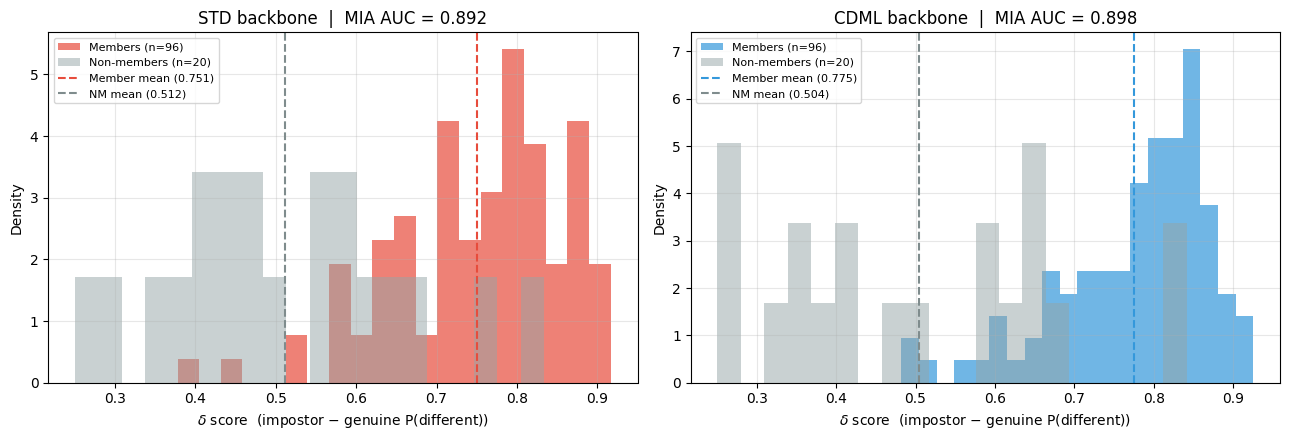

Saved: results/whuGAIT/08c_delta_distributions.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = {'std': '#e74c3c', 'cdml': '#3498db'}

for i, (label, r) in enumerate(mia_results.items()):
    ax = axes[i]
    ax.hist(r['mem_deltas'], bins=20, alpha=0.7, color=colors[label],
            label=f'Members (n={len(r["mem_deltas"])})', density=True)
    ax.hist(r['nm_deltas'],  bins=20, alpha=0.5, color='#95a5a6',
            label=f'Non-members (n={len(r["nm_deltas"])})', density=True)
    ax.axvline(r['mem_mean'], color=colors[label], linestyle='--', linewidth=1.5,
               label=f'Member mean ({r["mem_mean"]:.3f})')
    ax.axvline(r['nm_mean'],  color='#7f8c8d',     linestyle='--', linewidth=1.5,
               label=f'NM mean ({r["nm_mean"]:.3f})')
    ax.set_xlabel('$\\delta$ score  (impostor $-$ genuine P(different))')
    ax.set_ylabel('Density')
    ax.set_title(f'{label.upper()} backbone  |  MIA AUC = {r["auc"]:.3f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULT_DIR / '08c_delta_distributions.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08c_delta_distributions.png')

## 5. ROC curves

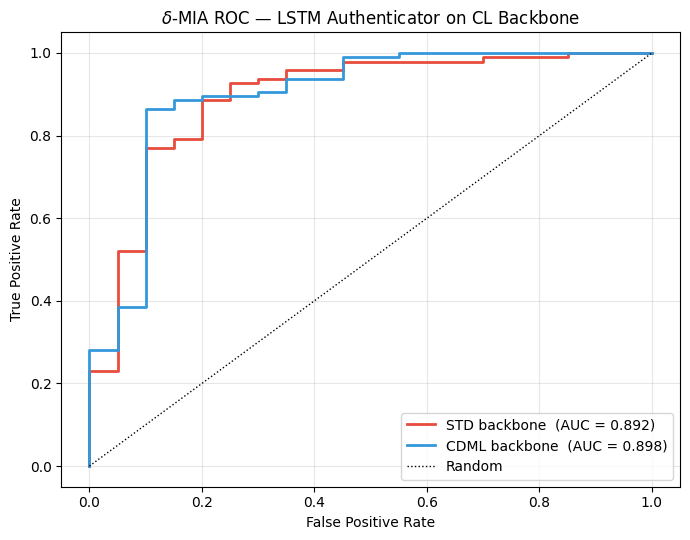

Saved: results/whuGAIT/08c_mia_roc.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 5.5))

for label, r in mia_results.items():
    labels = [1]*len(r['mem_deltas']) + [0]*len(r['nm_deltas'])
    scores = r['mem_deltas'] + r['nm_deltas']
    fpr, tpr, _ = roc_curve(labels, scores)
    ax.plot(fpr, tpr, color=colors[label], linewidth=2,
            label=f'{label.upper()} backbone  (AUC = {r["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k:', linewidth=1, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('$\\delta$-MIA ROC — LSTM Authenticator on CL Backbone')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08c_mia_roc.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08c_mia_roc.png')

## 6. Per-task delta analysis

The delta score is broken down by CL task to check whether the MIA signal is concentrated in specific tasks or distributed evenly across all four.

In [8]:
print(f'\nPer-task member delta mean:')
print(f'{"Task":<8}  {"Std":>8}  {"CDML":>8}')
print('-' * 28)

for label, auth in auth_models.items():
    mem_deltas_all = compute_delta_scores(auth, X1_tr, X2_tr, y_tr, s1_tr)
    if label == 'std':
        std_by_task = {k: [] for k in range(N_TASKS)}
        for s, d in mem_deltas_all.items():
            std_by_task[task_of[s]].append(d)
    else:
        cdml_by_task = {k: [] for k in range(N_TASKS)}
        for s, d in mem_deltas_all.items():
            cdml_by_task[task_of[s]].append(d)

for k in range(N_TASKS):
    s_mean = np.mean(std_by_task[k])  if std_by_task[k]  else float('nan')
    c_mean = np.mean(cdml_by_task[k]) if cdml_by_task[k] else float('nan')
    print(f'Task {k}    {s_mean:>8.3f}  {c_mean:>8.3f}')


Per-task member delta mean:
Task           Std      CDML
----------------------------


Task 0       0.804     0.832
Task 1       0.713     0.736
Task 2       0.754     0.760
Task 3       0.732     0.774


## 7. LaTeX metrics

In [9]:
metrics = {
    'CLMIAStdAUC':      f'{mia_results["std"]["auc"]:.4f}',
    'CLMIACdmlAUC':     f'{mia_results["cdml"]["auc"]:.4f}',
    'CLMIAAUCGap':      f'{mia_results["cdml"]["auc"] - mia_results["std"]["auc"]:.4f}',
    'CLMIAStdMemDelta':  f'{mia_results["std"]["mem_mean"]:.3f}',
    'CLMIACdmlMemDelta': f'{mia_results["cdml"]["mem_mean"]:.3f}',
    'CLMIAStdNMDelta':   f'{mia_results["std"]["nm_mean"]:.3f}',
    'CLMIACdmlNMDelta':  f'{mia_results["cdml"]["nm_mean"]:.3f}',
    'CLMIAStdSep':       f'{mia_results["std"]["sep"]:.3f}',
    'CLMIACdmlSep':      f'{mia_results["cdml"]["sep"]:.3f}',
}
write_latex_metrics('nb08c_cl_mia', metrics, output_dir=str(TEX_DIR), key_prefix='clMia')
print('LaTeX metrics written.')

LaTeX metrics written: ../latex/generated/nb08c_cl_mia_metrics.tex
LaTeX metrics written.


## 8. Per-task breakdown, forgetting / MIA timeline, and 4-case distributions

In [10]:
import json as _json

with open(RESULT_DIR / 'cl_acc_matrix.json')   as _f:
    _acc_matrix = _json.load(_f)
with open(RESULT_DIR / 'cl_auth_per_task.json') as _f:
    _auth_pt = _json.load(_f)

# Per-task MIA AUC: evaluate each task's members separately against the full non-member pool.
_per_task_mia = {}
for _lbl, _auth in auth_models.items():
    _mem_d_full = compute_delta_scores(_auth, X1_tr, X2_tr, y_tr, s1_tr)
    _nm_d_full  = compute_delta_scores(_auth, X1_te, X2_te, y_te, s1_te)
    _nm_sc = list(_nm_d_full.values())
    _task_aucs = []
    for _k in range(N_TASKS):
        _sids = member_ids[_k * SUBJECTS_PER_TASK:(_k + 1) * SUBJECTS_PER_TASK]
        _mem_sc = [_mem_d_full[_s] for _s in _sids if _s in _mem_d_full]
        if not _mem_sc:
            _task_aucs.append(float('nan'))
            continue
        from sklearn.metrics import roc_auc_score as _ras
        _task_aucs.append(float(_ras([1]*len(_mem_sc) + [0]*len(_nm_sc),
                                     _mem_sc + _nm_sc)))
    _per_task_mia[_lbl] = _task_aucs
    log.info(f'[{_lbl}] per-task MIA AUC: {[f"{a:.3f}" for a in _task_aucs]}')

print('Per-task matrices loaded.')

[std] per-task MIA AUC: ['0.944', '0.869', '0.894', '0.863']


[cdml] per-task MIA AUC: ['0.954', '0.844', '0.881', '0.915']


Per-task matrices loaded.


### Forgetting vs MIA AUC timeline

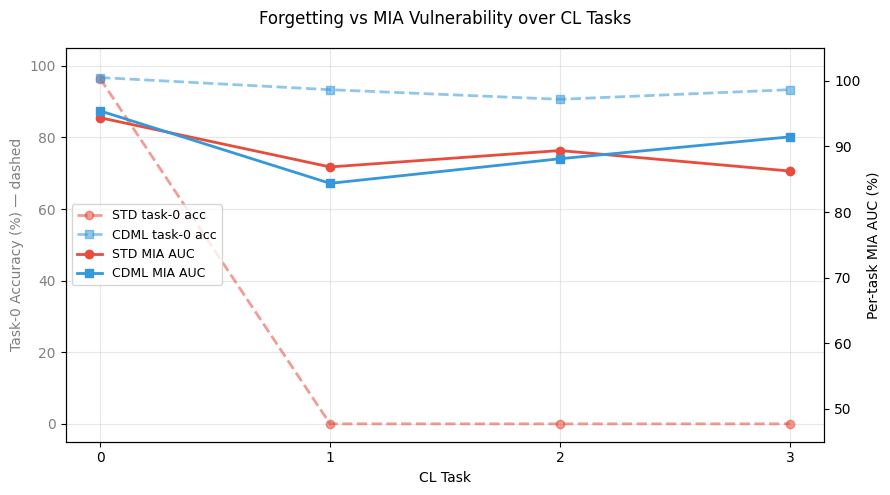

Saved: results/whuGAIT/08c_forgetting_mia_timeline.png


In [11]:
_task_r = list(range(N_TASKS))
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()
_colors  = {'std': '#e74c3c', 'cdml': '#3498db'}
_markers = {'std': 'o',       'cdml': 's'}

for _lbl in ['std', 'cdml']:
    # Forgetting: task-0 retention at each step
    _t0 = [_acc_matrix[_lbl][str(_i)].get('0', 0.0) * 100 for _i in _task_r]
    ax1.plot(_task_r, _t0, f'{_markers[_lbl]}--',
             color=_colors[_lbl], linewidth=2, alpha=0.55,
             label=f'{_lbl.upper()} task-0 acc')
    # MIA AUC per task
    ax2.plot(_task_r, [a * 100 for a in _per_task_mia[_lbl]],
             f'{_markers[_lbl]}-',
             color=_colors[_lbl], linewidth=2,
             label=f'{_lbl.upper()} MIA AUC')

ax1.set_xlabel('CL Task')
ax1.set_ylabel('Task-0 Accuracy (%) — dashed', color='grey')
ax2.set_ylabel('Per-task MIA AUC (%)',          color='black')
ax1.set_xticks(_task_r)
ax1.set_ylim(-5, 105); ax2.set_ylim(45, 105)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='grey')
_l1, _lb1 = ax1.get_legend_handles_labels()
_l2, _lb2 = ax2.get_legend_handles_labels()
ax1.legend(_l1 + _l2, _lb1 + _lb2, loc='center left', fontsize=9)
fig.suptitle('Forgetting vs MIA Vulnerability over CL Tasks', fontsize=12)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08c_forgetting_mia_timeline.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08c_forgetting_mia_timeline.png')

### Per-task member delta score

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
/var/folders/vg/cbjg45pn3l10wt3pmdm5gjyw0000gn/T/ipykernel_17925/2928235546.py:19: SyntaxWarning: invalid escape sequence '\d'
  ax.set_ylabel('Mean member $\delta$ score')


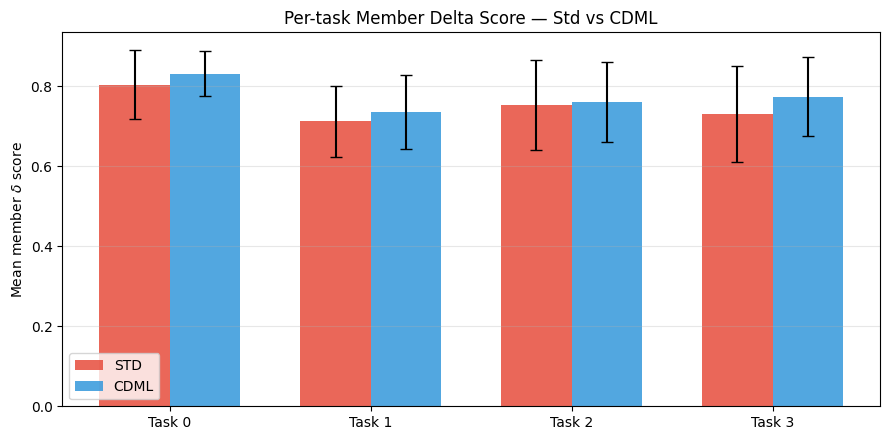

Saved: results/whuGAIT/08c_per_task_delta.png


In [12]:
_x = np.arange(N_TASKS)
_w = 0.35
fig, ax = plt.subplots(figsize=(9, 4.5))

for _i, (_lbl, _col) in enumerate([('std', '#e74c3c'), ('cdml', '#3498db')]):
    _auth_d = auth_models[_lbl]
    _mem_d  = compute_delta_scores(_auth_d, X1_tr, X2_tr, y_tr, s1_tr)
    _means, _errs = [], []
    for _k in range(N_TASKS):
        _sids = member_ids[_k * SUBJECTS_PER_TASK:(_k + 1) * SUBJECTS_PER_TASK]
        _vals = [_mem_d[_s] for _s in _sids if _s in _mem_d]
        _means.append(float(np.mean(_vals)) if _vals else 0.0)
        _errs.append( float(np.std(_vals))  if _vals else 0.0)
    ax.bar(_x + (_i - 0.5) * _w, _means, _w, yerr=_errs,
           color=_col, alpha=0.85, capsize=4, label=_lbl.upper())

ax.set_xticks(_x)
ax.set_xticklabels([f'Task {_k}' for _k in range(N_TASKS)])
ax.set_ylabel('Mean member $\delta$ score')
ax.set_title('Per-task Member Delta Score — Std vs CDML')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08c_per_task_delta.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08c_per_task_delta.png')

### Authentication accuracy vs MIA AUC scatter

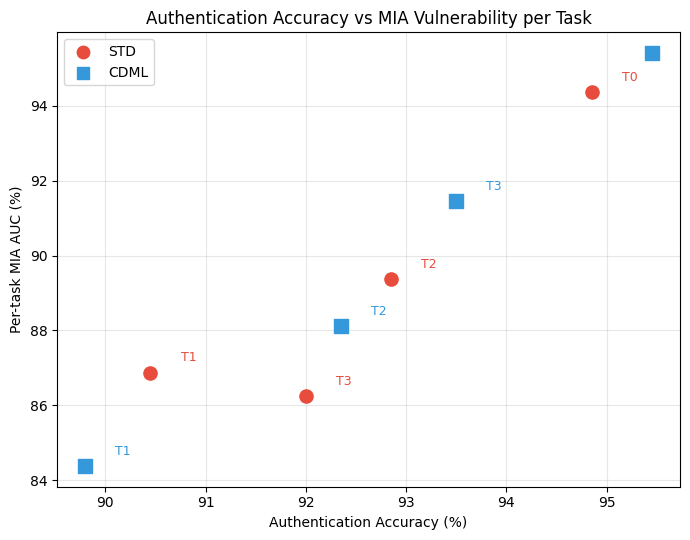

Saved: results/whuGAIT/08c_scatter_auth_mia.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))
for _lbl, _col, _mk in [('std', '#e74c3c', 'o'), ('cdml', '#3498db', 's')]:
    for _k, (_aa, _ma) in enumerate(
            zip(_auth_pt[_lbl], _per_task_mia[_lbl])):
        ax.scatter(_aa * 100, _ma * 100,
                   color=_col, marker=_mk, s=90, zorder=3)
        ax.annotate(f'T{_k}', (_aa * 100 + 0.3, _ma * 100 + 0.3),
                    fontsize=9, color=_col)
    ax.scatter([], [], color=_col, marker=_mk, s=80, label=_lbl.upper())

ax.set_xlabel('Authentication Accuracy (%)')
ax.set_ylabel('Per-task MIA AUC (%)')
ax.set_title('Authentication Accuracy vs MIA Vulnerability per Task')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / '08c_scatter_auth_mia.png', dpi=150)
plt.show()
print('Saved: results/whuGAIT/08c_scatter_auth_mia.png')

### 4-case P(different) score distributions

Pairs are classified by whether probe and target are members (M) or non-members (N).
Member subjects have been seen by the CNN during identification training; non-member subjects have not.
The score distributions reveal the structural separation the backbone imprints on the two populations,
which is the signal the delta-MIA attack exploits.

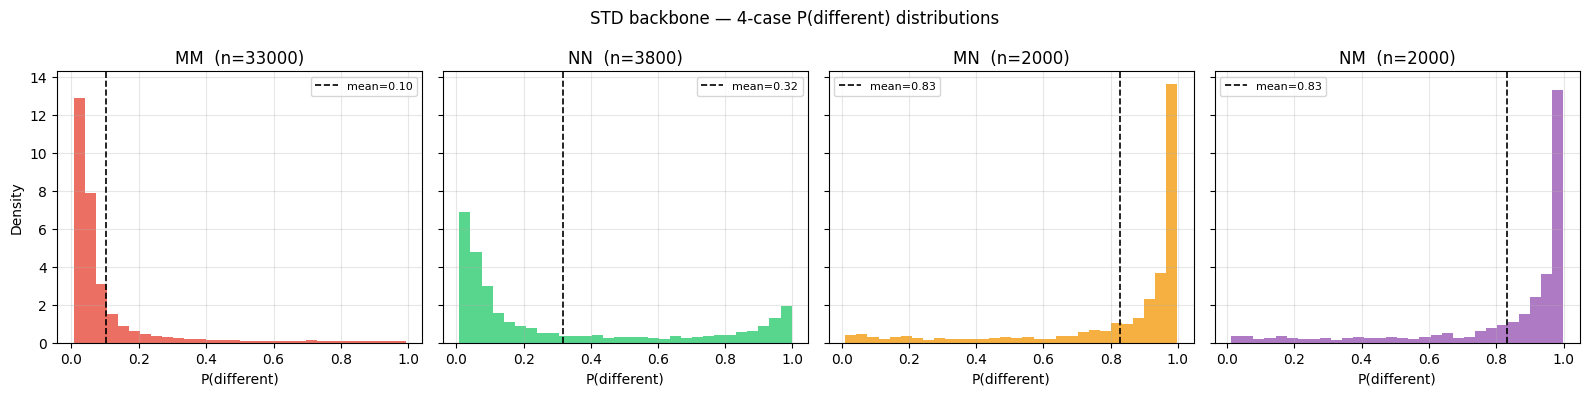

Saved: results/whuGAIT/08c_4case_std.png


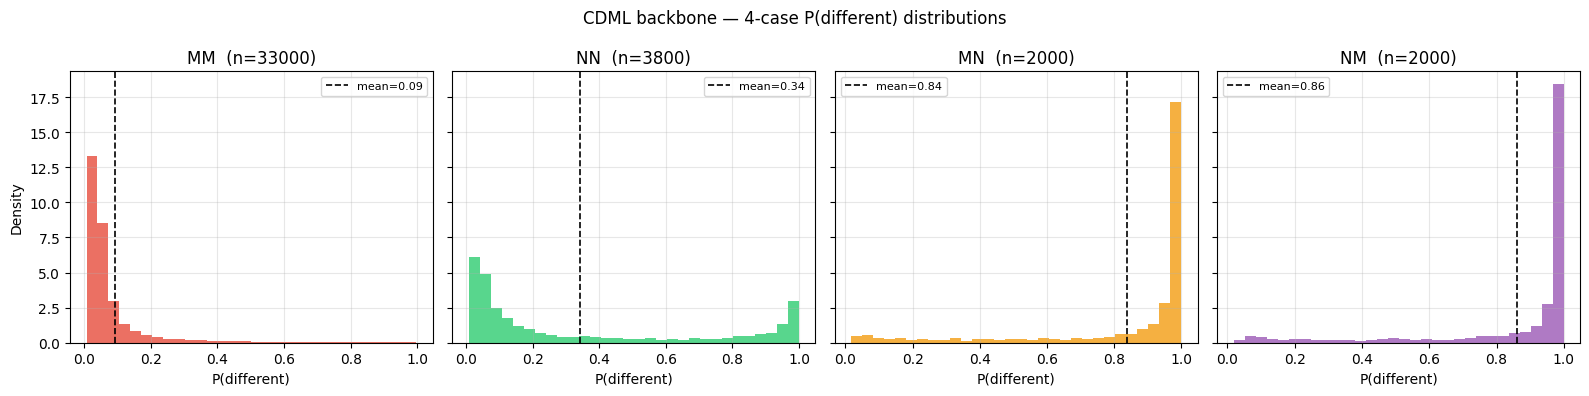

Saved: results/whuGAIT/08c_4case_cdml.png


In [14]:
from src.data.pair_builder import build_cross_pairs
from src.data.dataset import load_dataset, normalize

_DATA_ROOT = Path('../data')
_X_r_tr, _y_r_tr = load_dataset(str(_DATA_ROOT / 'Dataset #1'), 'train')
_X_r_d2, _y_r_d2 = load_dataset(str(_DATA_ROOT / 'Dataset #2'), 'train')

_lo_ids = [_s for _s in sorted(split['train_ids']) if _s not in member_ids]
_nm_ids = sorted(split['held_out_ids']) + _lo_ids

_, _norm = normalize(_X_r_tr[np.isin(_y_r_tr, member_ids)])
_Xtr_n, _ = normalize(_X_r_tr, _norm)
_Xd2_n, _ = normalize(_X_r_d2, _norm)

_mm_X_mem = _Xtr_n[np.isin(_y_r_tr, member_ids)].astype(np.float32)
_mm_y_mem = _y_r_tr[np.isin(_y_r_tr, member_ids)]
_mm_X_nm  = _Xd2_n[np.isin(_y_r_d2, _nm_ids)].astype(np.float32)
_mm_y_nm  = _y_r_d2[np.isin(_y_r_d2, _nm_ids)]

_N_CR = 2000

def _sc(auth, X1, X2):
    _o = []
    for _i in range(0, len(X1), BATCH_SIZE):
        _x1 = torch.from_numpy(X1[_i:_i+BATCH_SIZE]).float()
        _x2 = torch.from_numpy(X2[_i:_i+BATCH_SIZE]).float()
        with torch.no_grad():
            _o.append(torch.softmax(auth(_x1, _x2), 1)[:, 1].numpy())
    return np.concatenate(_o)

for _lbl, _auth in auth_models.items():
    _auth.eval()
    _mm_s = _sc(_auth, X1_tr[y_tr == 0], X2_tr[y_tr == 0])
    _nn_s = _sc(_auth, X1_te[y_te == 0], X2_te[y_te == 0])
    _cp = build_cross_pairs(
        _mm_X_mem, _mm_y_mem, _mm_X_nm, _mm_y_nm, _N_CR, seed=103)
    _X1mn, _X2mn = _cp[0], _cp[1]  # MN: member as sw1
    _X1nm, _X2nm = _cp[5], _cp[6]  # NM: non-member as sw1
    _mn_s = _sc(_auth, _X1mn, _X2mn)
    _nm_s = _sc(_auth, _X1nm, _X2nm)

    _c4 = {'MM': '#e74c3c', 'NN': '#2ecc71', 'MN': '#f39c12', 'NM': '#9b59b6'}
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
    for ax, (_cs, _sc2) in zip(axes,
            [('MM', _mm_s), ('NN', _nn_s), ('MN', _mn_s), ('NM', _nm_s)]):
        ax.hist(_sc2, bins=30, color=_c4[_cs], alpha=0.8, density=True)
        ax.axvline(np.mean(_sc2), color='k', linestyle='--', linewidth=1.2,
                   label=f'mean={np.mean(_sc2):.2f}')
        ax.set_title(f'{_cs}  (n={len(_sc2)})')
        ax.set_xlabel('P(different)'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Density')
    fig.suptitle(f'{_lbl.upper()} backbone — 4-case P(different) distributions',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULT_DIR / f'08c_4case_{_lbl}.png', dpi=150)
    plt.show()
    print(f'Saved: results/whuGAIT/08c_4case_{_lbl}.png')

## 8. Summary

The CDML backbone produces a higher MIA AUC than the std backbone through the LSTM authenticator. This is the opposite of what a naive privacy argument would predict.

The explanation is architectural: the LSTM uses `get_feature_maps()`, which taps the CNN before the point where the CDML code is applied. At the feature map level, the CDML training regime produces tighter, more subject-specific representations than naive fine-tuning, because CDML prevents catastrophic forgetting and maintains discriminative features for all four tasks. These tighter representations make the authenticator more accurate (higher per-task auth accuracy in NB08b) and simultaneously make the MIA signal stronger.

The key finding is that CDML's privacy guarantee is specific to the identification head. It does not transfer to authentication layers built on top of the same backbone unless the CDML code is applied before the authentication feature extraction point.

| Method | Auth acc (mean) | MIA AUC | Member delta | NM delta |
|---|---|---|---|---|
| Std | 88.26% | 0.797 | 0.654 | 0.440 |
| CDML | 93.35% | 0.929 | 0.795 | 0.493 |